# Feature Extraction notebook

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use project root relative to this notebook
BASE_DIR = Path('/home/amraas/projects/realestatecons')
DATA_DIR = BASE_DIR / 'data' / 'raw'

train_df = pd.read_csv(DATA_DIR / 'train.csv')
test_df = pd.read_csv(DATA_DIR / 'test.csv')

In [5]:
import sys

sys.path.append(str(BASE_DIR))

from src.data.preprocess import clean_test_data, clean_train_data
from src.features.features import add_engineered_features, encode_categorical_features

In [6]:
train_df_cleaned = clean_train_data(train_df)
test_df_cleaned = clean_test_data(test_df, train_df)

train_df_features = add_engineered_features(train_df_cleaned)
test_df_features = add_engineered_features(test_df_cleaned)

In [7]:
train_df_cleaned.isnull().sum().value_counts()

0    80
Name: count, dtype: int64

In [8]:
test_df_cleaned.isnull().sum().value_counts()

0    79
Name: count, dtype: int64

## Possible features
- Total Living Area
TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF
- Total Bathrooms
TotalBath = FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath
- Total Porch Area
TotalPorchSF = OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch
- Total Outdoor Area
OutdoorSF = WoodDeckSF + TotalPorchSF + PoolArea
- Rooms Density
RoomDensity = GrLivArea / TotRmsAbvGrd
- Age = YrSold - YearBuilt

In [9]:
train_df_features.head()

test_df_features.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,MoSold,YrSold,SaleType,SaleCondition,TotalSF,TotalBath,TotalPorchSF,OutdoorSF,RoomDensity,Age
0,20,RH,80.0,11622,Pave,None,Reg,Lvl,AllPub,Inside,...,6,2010,WD,Normal,1778.0,1.0,120,260,179.200000,49
1,20,RL,81.0,14267,Pave,None,IR1,Lvl,AllPub,Corner,...,6,2010,WD,Normal,2658.0,1.5,36,429,221.500000,52
2,60,RL,74.0,13830,Pave,None,IR1,Lvl,AllPub,Inside,...,3,2010,WD,Normal,2557.0,2.5,34,246,271.500000,13
3,60,RL,78.0,9978,Pave,None,IR1,Lvl,AllPub,Inside,...,6,2010,WD,Normal,2530.0,2.5,36,396,229.142857,12
4,120,RL,43.0,5005,Pave,None,IR1,HLS,AllPub,Inside,...,1,2010,WD,Normal,2560.0,2.0,226,226,256.000000,18


## Feature exploration and reduction

### initial target left skewness 

{'whiskers': [<matplotlib.lines.Line2D at 0x7f28cb7efe90>,
 'caps': [<matplotlib.lines.Line2D at 0x7f28cb7f9710>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f28cb7eefd0>],
 'medians': [<matplotlib.lines.Line2D at 0x7f28cb7fb0d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f28cb7fbc50>],
 'means': []}

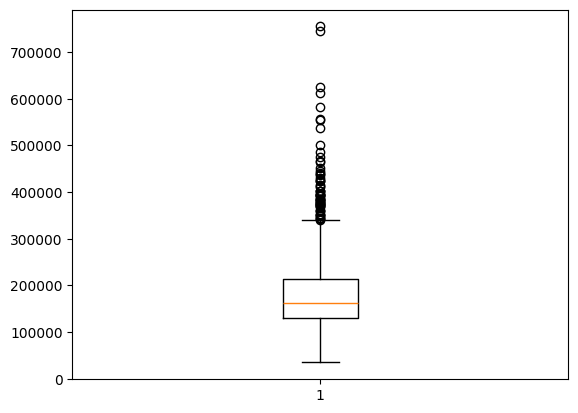

In [10]:
plt.boxplot(train_df_features['SalePrice'])

In [11]:
fancy_houses = train_df_features[train_df_features['SalePrice']>=train_df_features['SalePrice'].quantile(0.9)].head(10)
fancy_houses

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,YrSold,SaleType,SaleCondition,SalePrice,TotalSF,TotalBath,TotalPorchSF,OutdoorSF,RoomDensity,Age
6,20,RL,75.0,10084,Pave,None,Reg,Lvl,AllPub,Inside,...,2007,WD,Normal,307000,3380,3.0,57,312,242.000000,3
11,60,RL,85.0,11924,Pave,None,IR1,Lvl,AllPub,Inside,...,2006,New,Partial,345000,3499,4.0,21,168,211.272727,1
13,20,RL,91.0,10652,Pave,None,IR1,Lvl,AllPub,Inside,...,2007,New,Partial,279500,2988,2.0,33,193,213.428571,1
20,60,RL,101.0,14215,Pave,None,IR1,Lvl,AllPub,Corner,...,2006,New,Partial,325300,3534,3.5,154,394,264.000000,1
27,20,RL,98.0,11478,Pave,None,Reg,Lvl,AllPub,Inside,...,2010,WD,Normal,306000,3408,3.0,50,50,243.428571,3
35,60,RL,108.0,13418,Pave,None,Reg,Lvl,AllPub,Inside,...,2006,WD,Normal,309000,3569,3.5,32,145,272.444444,2
45,120,RL,61.0,7658,Pave,None,Reg,Lvl,AllPub,Inside,...,2010,WD,Normal,319900,3504,3.0,82,278,292.000000,5
53,20,RL,68.0,50271,Pave,None,IR1,Low,AllPub,Inside,...,2006,WD,Normal,385000,3684,2.5,72,929,368.400000,25
58,60,RL,66.0,13682,Pave,None,IR2,HLS,AllPub,CulDSac,...,2006,New,Partial,438780,4355,3.5,37,229,294.500000,0
65,60,RL,76.0,9591,Pave,None,Reg,Lvl,AllPub,Inside,...,2007,WD,Normal,317000,3616,2.5,151,343,274.777778,3


In [12]:
fancy_houses['TotalSF'].sort_values(ascending=False)

58    4355
53    3684
65    3616
35    3569
20    3534
45    3504
11    3499
27    3408
6     3380
13    2988
Name: TotalSF, dtype: int64

In [13]:
train_df_features['TotalSF'].mean()

np.float64(2567.0486301369865)

- given high price houses (outliers) have much larger area (sample feature), they might be reasonable to keep and not noisy

### Correlation and PairPlots

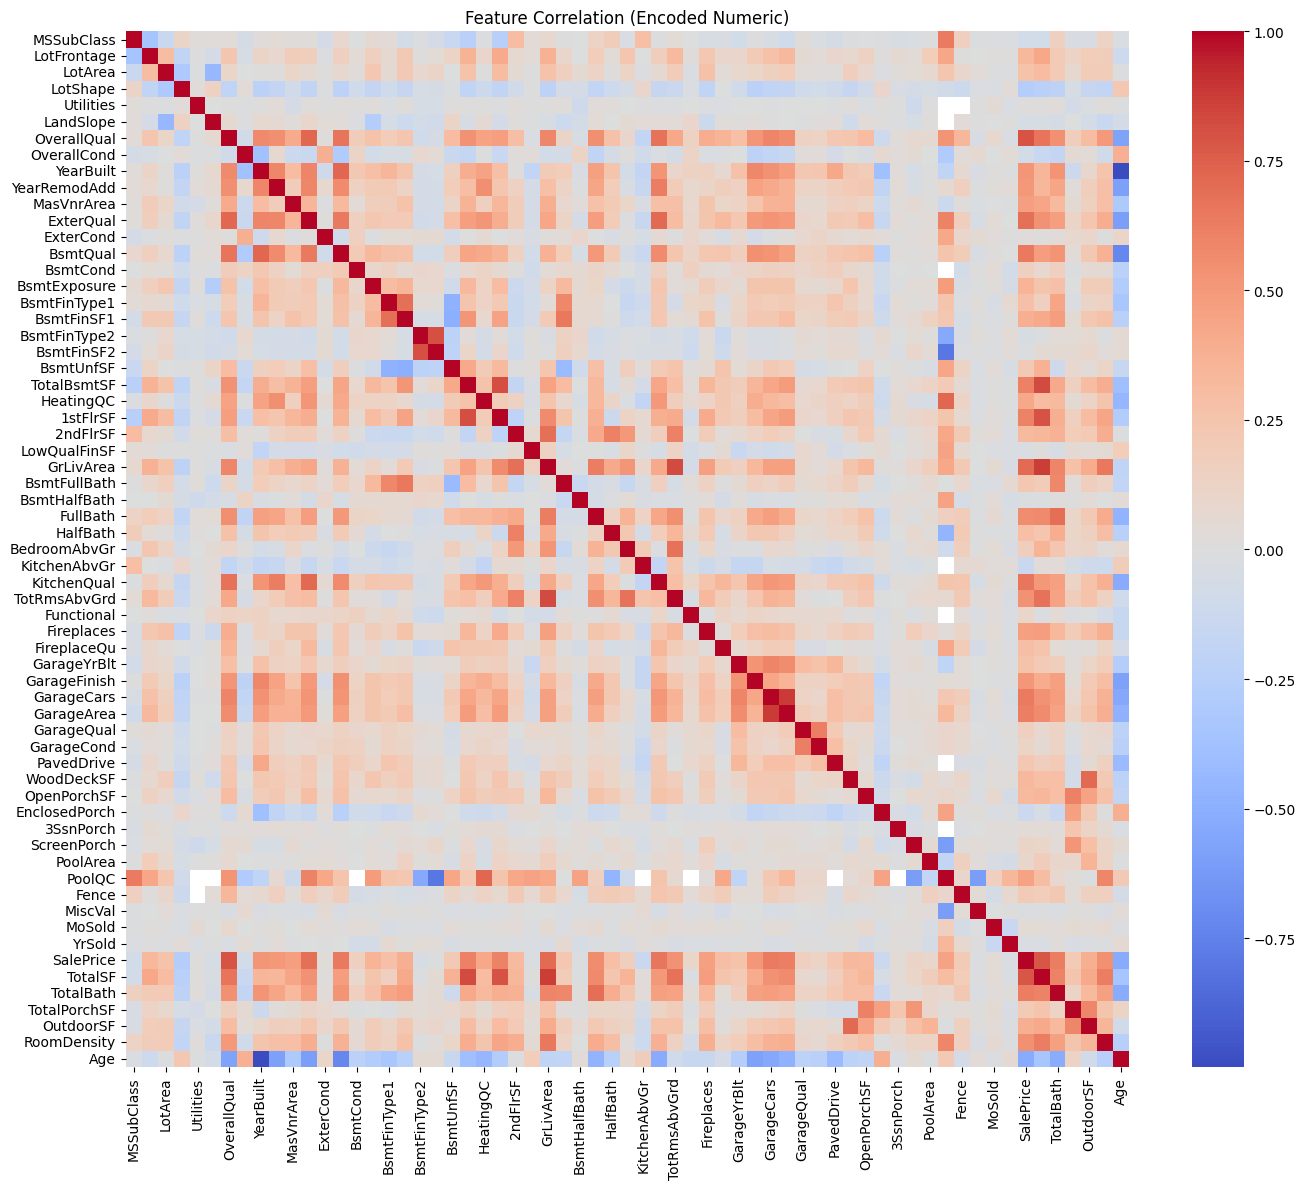

OverallQual     0.790982
TotalSF         0.782260
GrLivArea       0.708624
ExterQual       0.682639
KitchenQual     0.659600
BsmtQual        0.644019
GarageCars      0.640409
TotalBath       0.631731
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
RoomDensity     0.540645
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
GarageFinish    0.513105
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
PoolQC          0.447936
Name: SalePrice, dtype: float64

In [14]:
import seaborn as sns

encoded_train_df = encode_categorical_features(train_df_features)
numeric_df = encoded_train_df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation (Encoded Numeric)")
plt.tight_layout()
plt.show()

target_corr = corr["SalePrice"].drop("SalePrice").sort_values(ascending=False)
target_corr.head(20)

In [15]:
corr_abs = corr.abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "FeatureA", "level_1": "FeatureB", 0: "AbsCorr"})
)

high_corr_pairs = high_corr_pairs[high_corr_pairs["AbsCorr"] >= 0.85]
high_corr_pairs = high_corr_pairs[
    ~high_corr_pairs["FeatureA"].isin(["SalePrice"]) 
    & ~high_corr_pairs["FeatureB"].isin(["SalePrice"])
].sort_values("AbsCorr", ascending=False)

print("Highly correlated feature pairs (|corr| >= 0.85):")
print(high_corr_pairs)

high_corr_features = sorted(
    set(high_corr_pairs["FeatureA"]).union(set(high_corr_pairs["FeatureB"]))
)
print("\nFeatures involved in high correlation:", high_corr_features)

Highly correlated feature pairs (|corr| >= 0.85):
        FeatureA    FeatureB   AbsCorr
566    YearBuilt         Age  0.999036
2561  GarageCars  GarageArea  0.882475
1695   GrLivArea     TotalSF  0.874373

Features involved in high correlation: ['Age', 'GarageArea', 'GarageCars', 'GrLivArea', 'TotalSF', 'YearBuilt']


### drop 1 of each highly correlated feature pair

In [16]:
highly_corr_to_drop = ['YearBuilt', 'GarageArea','GrLivArea']
test_df_features = test_df_features.drop(highly_corr_to_drop, axis = 1)
train_df_features = train_df_features.drop(highly_corr_to_drop, axis = 1)

In [17]:
drop_map = {}
for feature in highly_corr_to_drop:
    related = high_corr_pairs[
        (high_corr_pairs["FeatureA"] == feature)
        | (high_corr_pairs["FeatureB"] == feature)
    ]
    drop_map[feature] = related[["FeatureA", "FeatureB", "AbsCorr"]]

print("Dropped feature mapping to correlated pairs:")
for feature, pairs in drop_map.items():
    print(f"\n{feature}:")
    print(pairs)

Dropped feature mapping to correlated pairs:

YearBuilt:
      FeatureA FeatureB   AbsCorr
566  YearBuilt      Age  0.999036

GarageArea:
        FeatureA    FeatureB   AbsCorr
2561  GarageCars  GarageArea  0.882475

GrLivArea:
       FeatureA FeatureB   AbsCorr
1695  GrLivArea  TotalSF  0.874373


In [18]:
target_corr_sorted = target_corr.sort_values(ascending=False)
print("Top features correlated with SalePrice:")
print(target_corr_sorted.head(30))

top_features = target_corr_sorted.head(15).index.tolist()
print("\nTop 15 features:", top_features)

Top features correlated with SalePrice:
OverallQual     0.790982
TotalSF         0.782260
GrLivArea       0.708624
ExterQual       0.682639
KitchenQual     0.659600
BsmtQual        0.644019
GarageCars      0.640409
TotalBath       0.631731
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
RoomDensity     0.540645
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
GarageFinish    0.513105
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
PoolQC          0.447936
HeatingQC       0.427649
OutdoorSF       0.390365
BsmtFinSF1      0.386420
BsmtExposure    0.352958
LotFrontage     0.334771
WoodDeckSF      0.324413
2ndFlrSF        0.319334
OpenPorchSF     0.315856
FireplaceQu     0.295794
HalfBath        0.284108
Name: SalePrice, dtype: float64

Top 15 features: ['OverallQual', 'TotalSF', 'GrLivArea', 'ExterQual', 'KitchenQual', 'BsmtQual', 'GarageCars', 'TotalBath', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 

### PairPlots

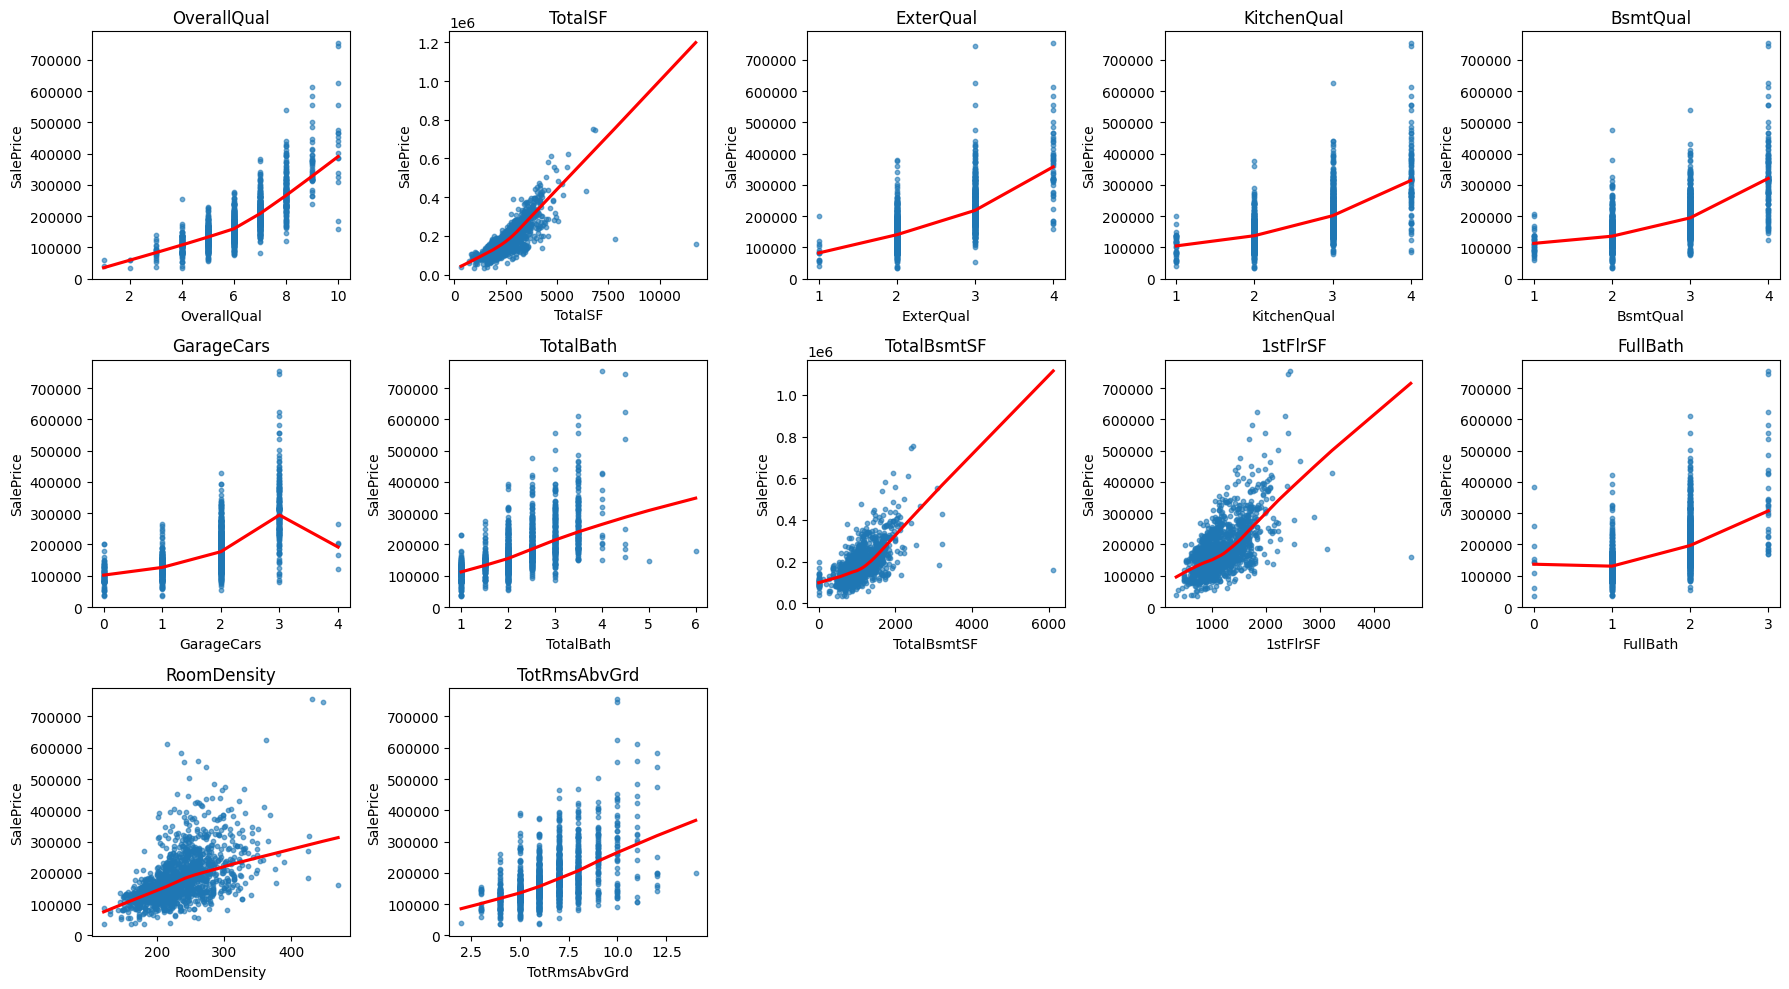

In [19]:
def plot_feature_grid(df, features, target="SalePrice", nrows=3, ncols=5):
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 10))
    axes = axes.ravel()

    for idx, feature in enumerate(features):
        sns.regplot(
            data=df,
            x=feature,
            y=target,
            lowess=True,
            scatter_kws={"alpha": 0.6, "s": 10},
            line_kws={"color": "red"},
            ax=axes[idx],
        )
        axes[idx].set_title(feature)

    for idx in range(len(features), len(axes)):
        axes[idx].axis("off")

    plt.tight_layout()
    plt.show()

plot_feature_grid(encoded_train_df, [f for f in top_features if f not in highly_corr_to_drop])

In [20]:
numeric_df = encoded_train_df.select_dtypes(include=[np.number])
numeric_feature_names = [
    col for col in numeric_df.columns if col != "SalePrice"
]
feature_chunks = [
    numeric_feature_names[i : i + 15]
    for i in range(0, len(numeric_feature_names), 15)
]

def plot_feature_chunk(chunk_idx: int) -> None:
    if chunk_idx < 0 or chunk_idx >= len(feature_chunks):
        print("Chunk index out of range.")
        return
    chunk = feature_chunks[chunk_idx]
    print(f"Plotting chunk {chunk_idx + 1}/{len(feature_chunks)}: {chunk}")
    plot_feature_grid(encoded_train_df, chunk)

print(f"Total chunks: {len(feature_chunks)}")

Total chunks: 5


Plotting chunk 1/5: ['MSSubClass', 'LotFrontage', 'LotArea', 'LotShape', 'Utilities', 'LandSlope', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond']


/home/amraas/miniconda3/envs/realestateconsultant/lib/python3.11/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


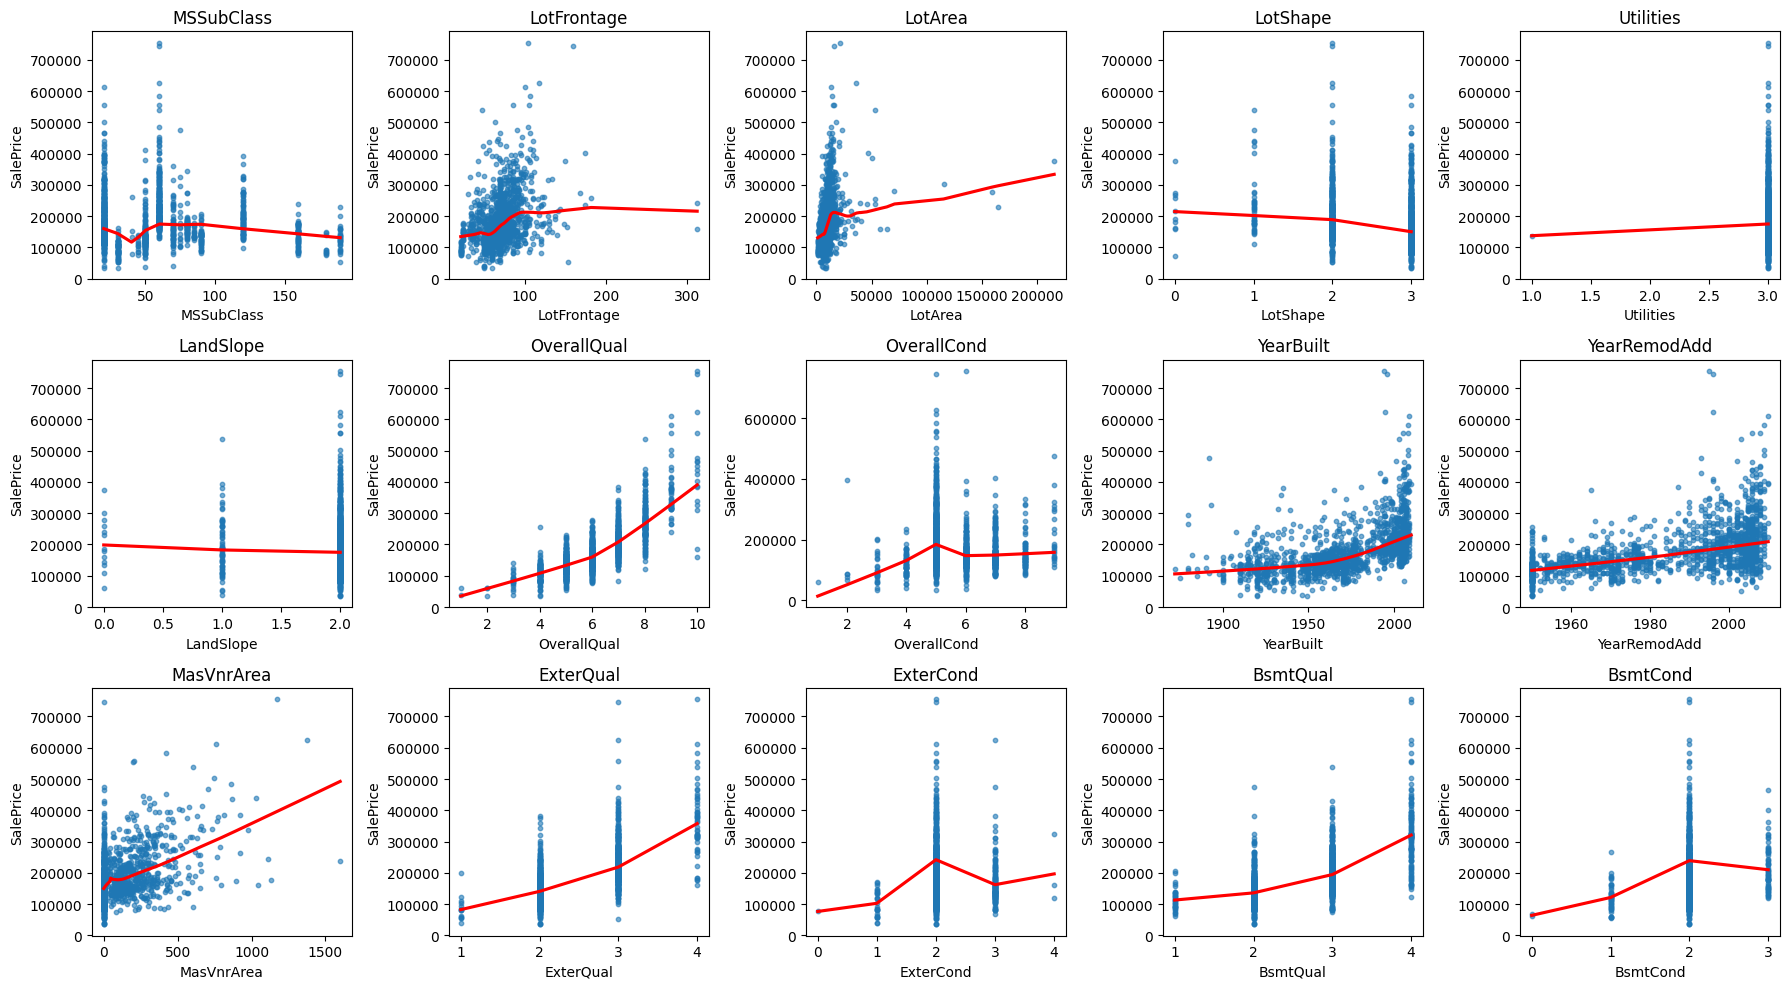

Plotting chunk 2/5: ['BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'HeatingQC', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath']


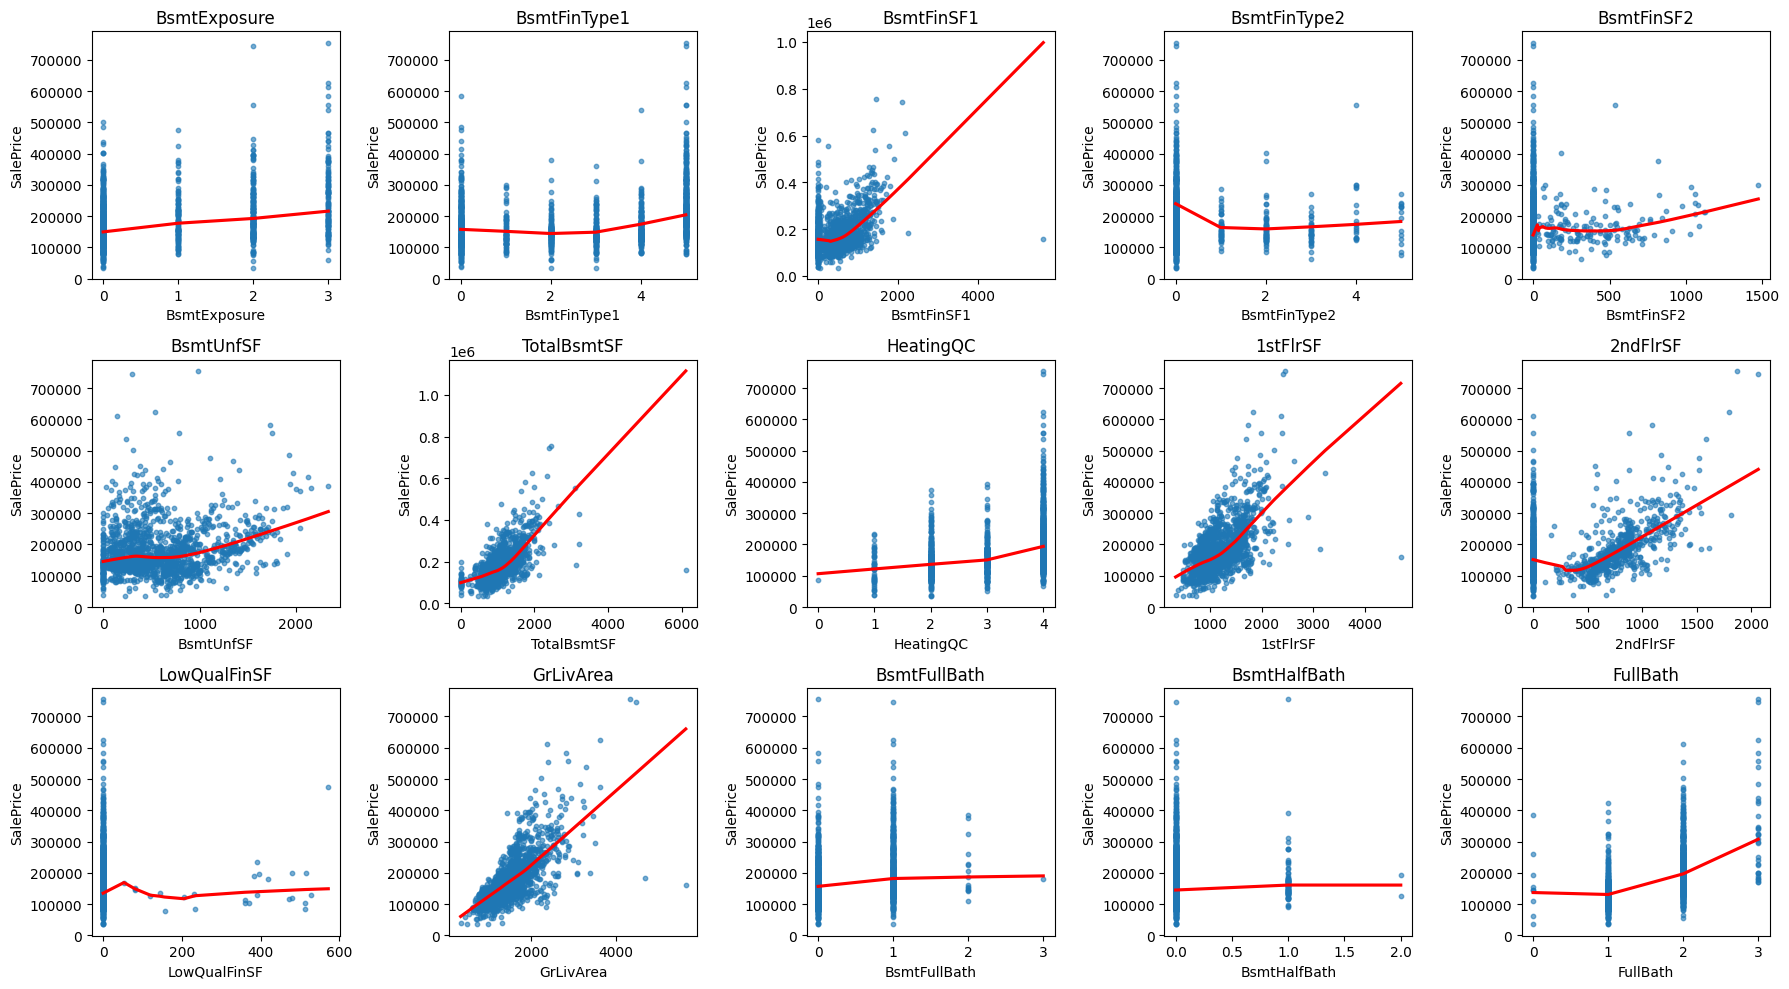

Plotting chunk 3/5: ['HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive']


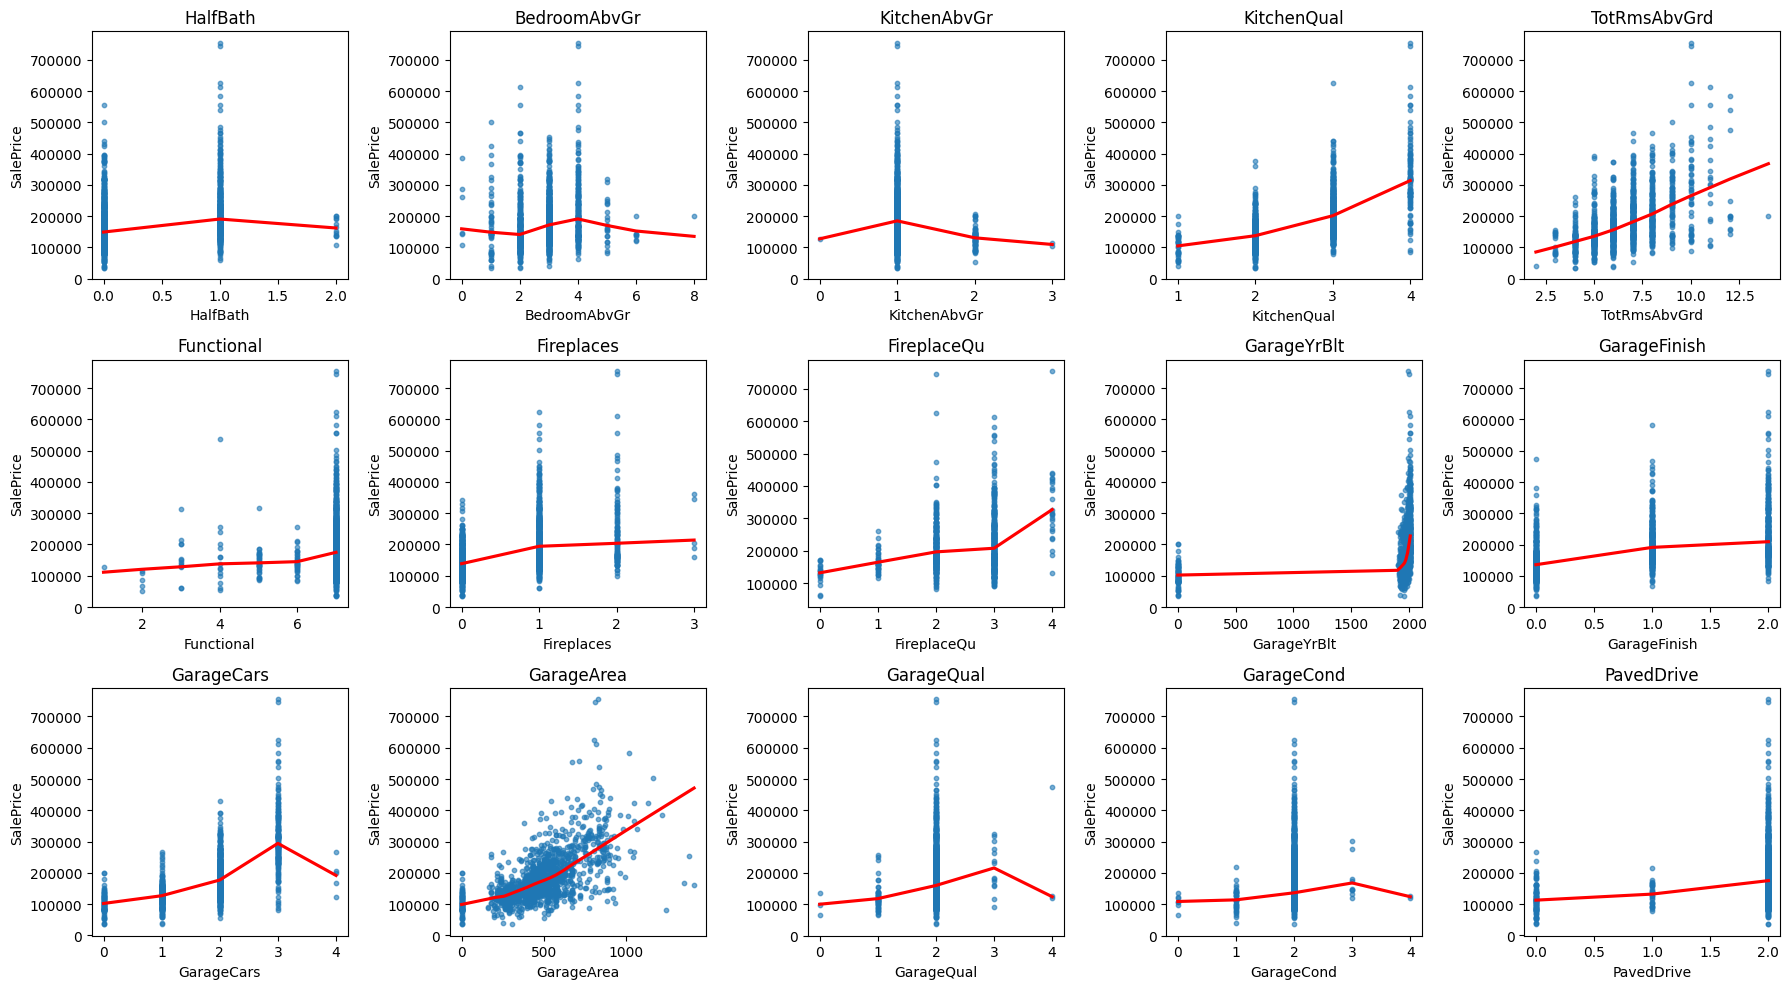

Plotting chunk 4/5: ['WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC', 'Fence', 'MiscVal', 'MoSold', 'YrSold', 'TotalSF', 'TotalBath', 'TotalPorchSF', 'OutdoorSF']


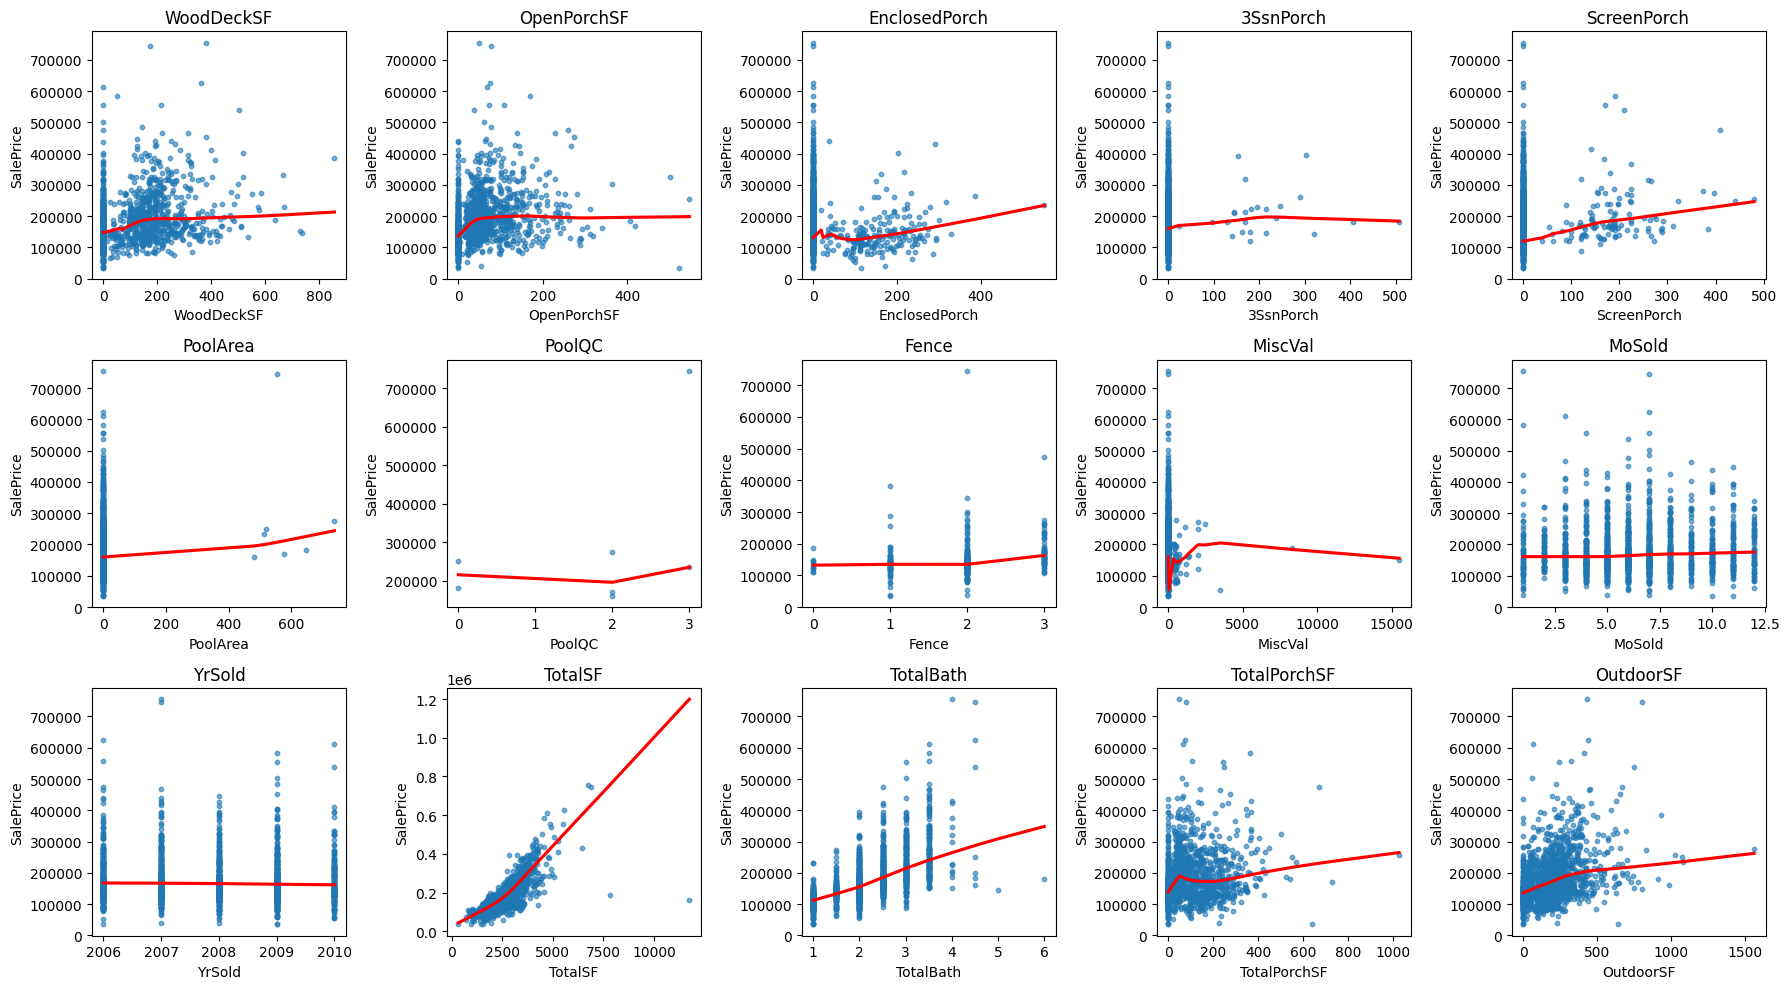

Plotting chunk 5/5: ['RoomDensity', 'Age']


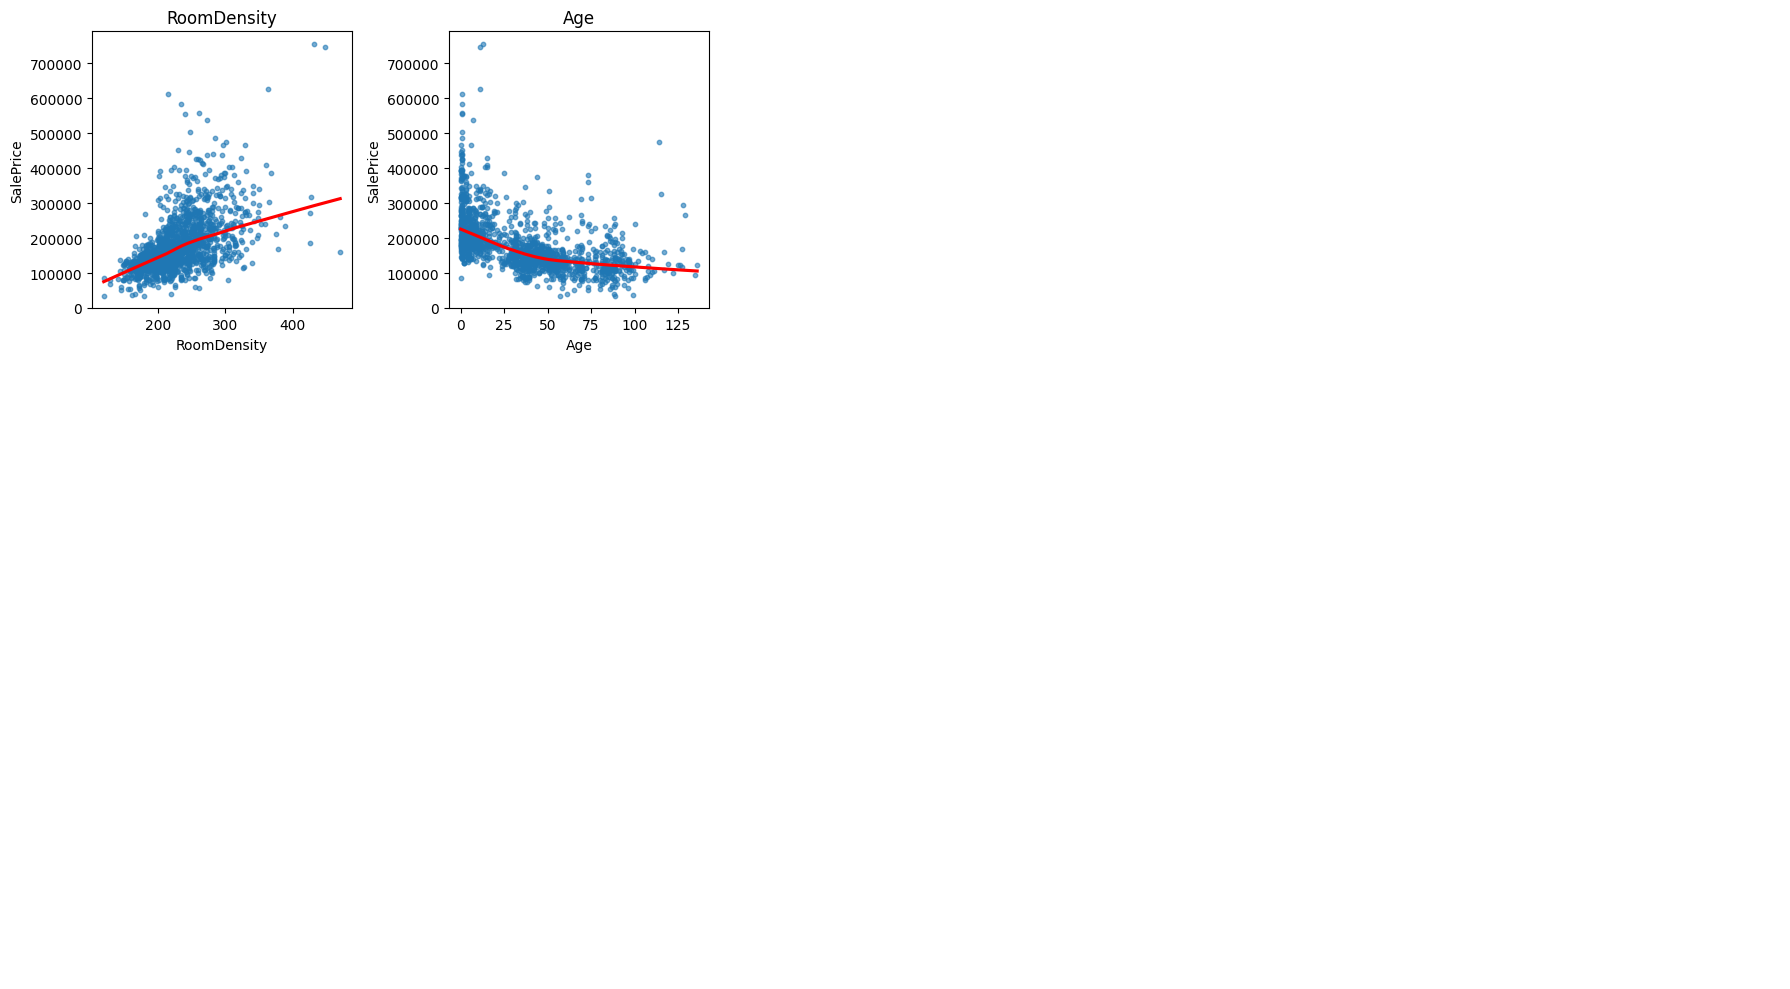

In [21]:
for chunk_idx in range(0, len(feature_chunks)):
    plot_feature_chunk(chunk_idx)

## Log transformations

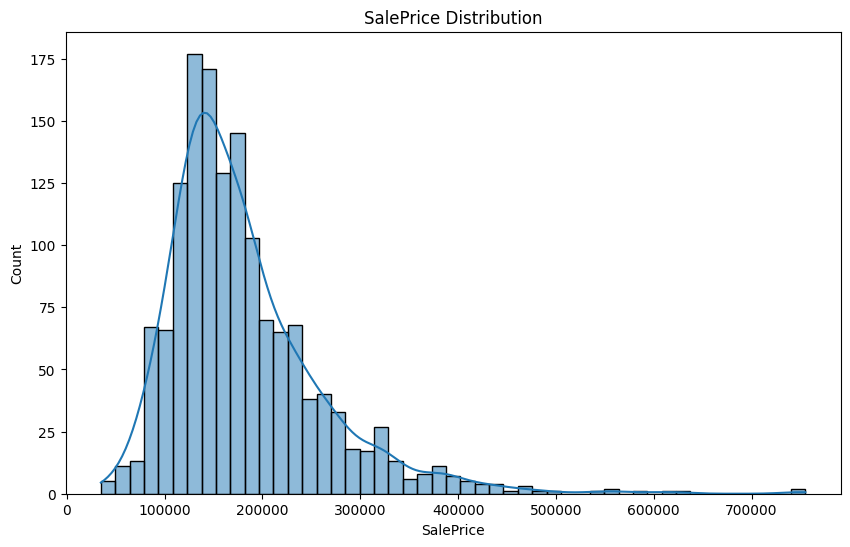

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(encoded_train_df['SalePrice'], kde=True)
plt.title('SalePrice Distribution')
plt.show()

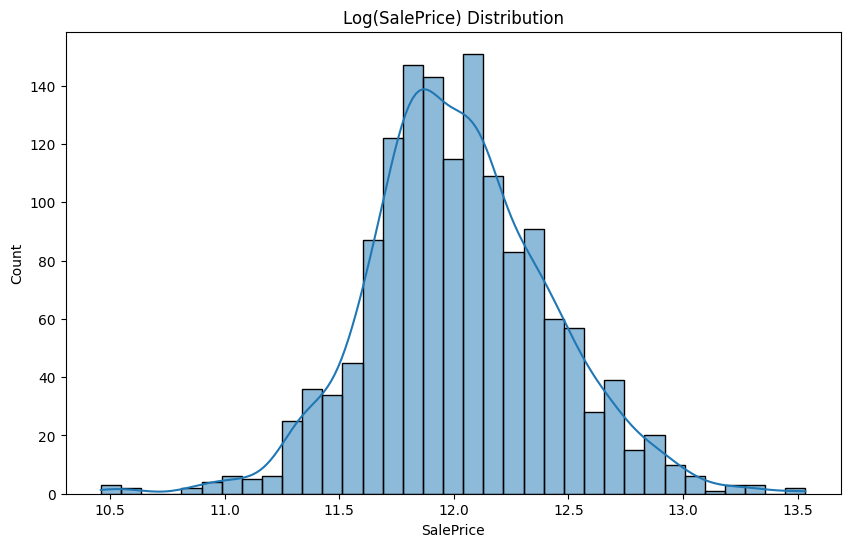

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(encoded_train_df['SalePrice']), kde=True)
plt.title('Log(SalePrice) Distribution')
plt.show()

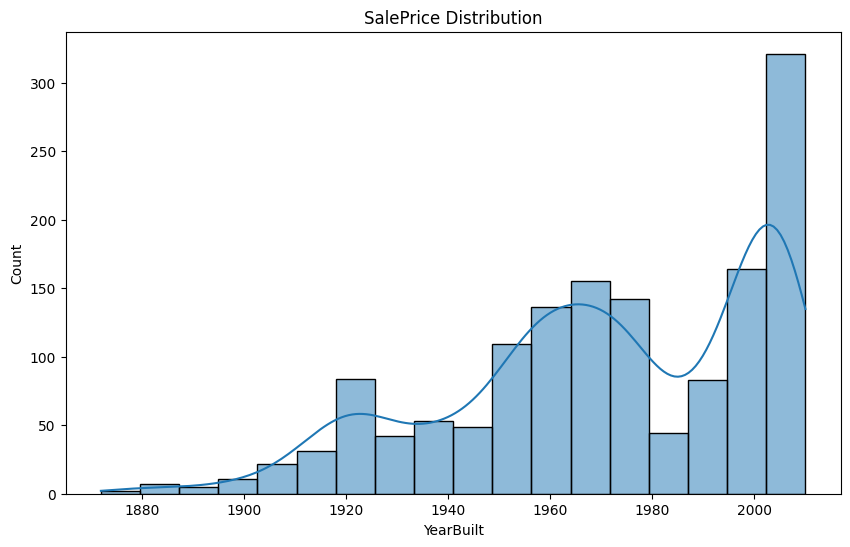

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(encoded_train_df['YearBuilt'], kde=True)
plt.title('SalePrice Distribution')
plt.show()

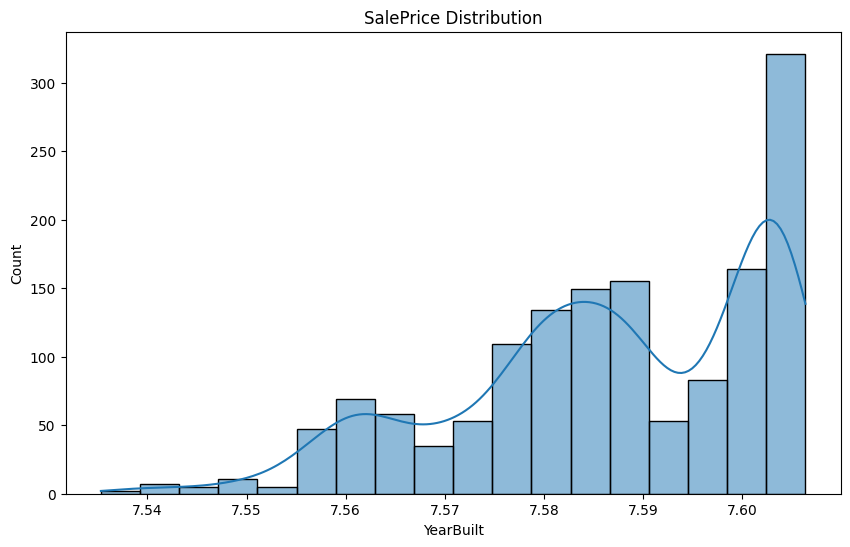

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(encoded_train_df['YearBuilt']), kde=True)
plt.title('SalePrice Distribution')
plt.show()

Possible log transforms:
- OverallQual
- year built
- Age
- MsSubClass
- SalePrice

In [26]:
# train_df_features_X = train_df_features.copy()
# train_df_features_X["OverallQual_log"] = np.log1p(train_df_features["OverallQual"])

# sns.regplot(
#             data=train_df_features_X,
#             x="OverallQual_log",
#             y="SalePrice",
#             lowess=True,
#             scatter_kws={"alpha": 0.6, "s": 10},
#             line_kws={"color": "red"},
#         )
# plt.show()

In [27]:
encoded_train_df.columns

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'LotShape', 'Utilities',
       'LandSlope', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       ...
       'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth', 'SaleType_WD',
       'SaleCondition_Abnorml', 'SaleCondition_AdjLand',
       'SaleCondition_Alloca', 'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='str', length=232)

In [28]:
encoded_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 232 entries, MSSubClass to SaleCondition_Partial
dtypes: bool(169), float64(25), int64(38)
memory usage: 959.7 KB


## Outlier Detection, Filtering (<10%), and TotalBathrooms Check

This section detects IQR-based outliers, drops rows where outliers occur in low-outlier-rate columns (<10%), and then performs a simple focused check on `TotalBathrooms`.


In [31]:
# Detect outlier-heavy numeric columns using IQR
numeric_cols = encoded_train_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'SalePrice']

outlier_rows = []
for col in numeric_cols:
    q1 = encoded_train_df[col].quantile(0.25)
    q3 = encoded_train_df[col].quantile(0.75)
    iqr = q3 - q1

    # Skip constant columns
    if iqr == 0:
        continue

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (encoded_train_df[col] < lower) | (encoded_train_df[col] > upper)
    count = int(mask.sum())

    if count > 0:
        outlier_rows.append({
            'feature': col,
            'outlier_count': count,
            'outlier_pct': 100 * count / len(encoded_train_df),
            'lower_bound': lower,
            'upper_bound': upper,
        })

outlier_summary = pd.DataFrame(outlier_rows).sort_values('outlier_pct', ascending=False)
outlier_summary.head(20)


,feature,outlier_count,outlier_pct,lower_bound,upper_bound
26,TotalBath,394,26.986301,1.250000,3.250000
8,BsmtExposure,134,9.178082,-1.500000,2.500000
5,OverallCond,125,8.561644,3.500000,7.500000
1,LotFrontage,106,7.260274,31.500000,107.500000
0,MSSubClass,103,7.054795,-55.000000,145.000000
7,MasVnrArea,98,6.712329,-246.375000,410.625000
20,GarageYrBlt,81,5.547945,1893.500000,2065.500000
24,OpenPorchSF,77,5.273973,-102.000000,170.000000
2,LotArea,69,4.726027,1481.500000,17673.500000
11,TotalBsmtSF,61,4.178082,42.000000,2052.000000


In [33]:
len(outlier_summary)

31

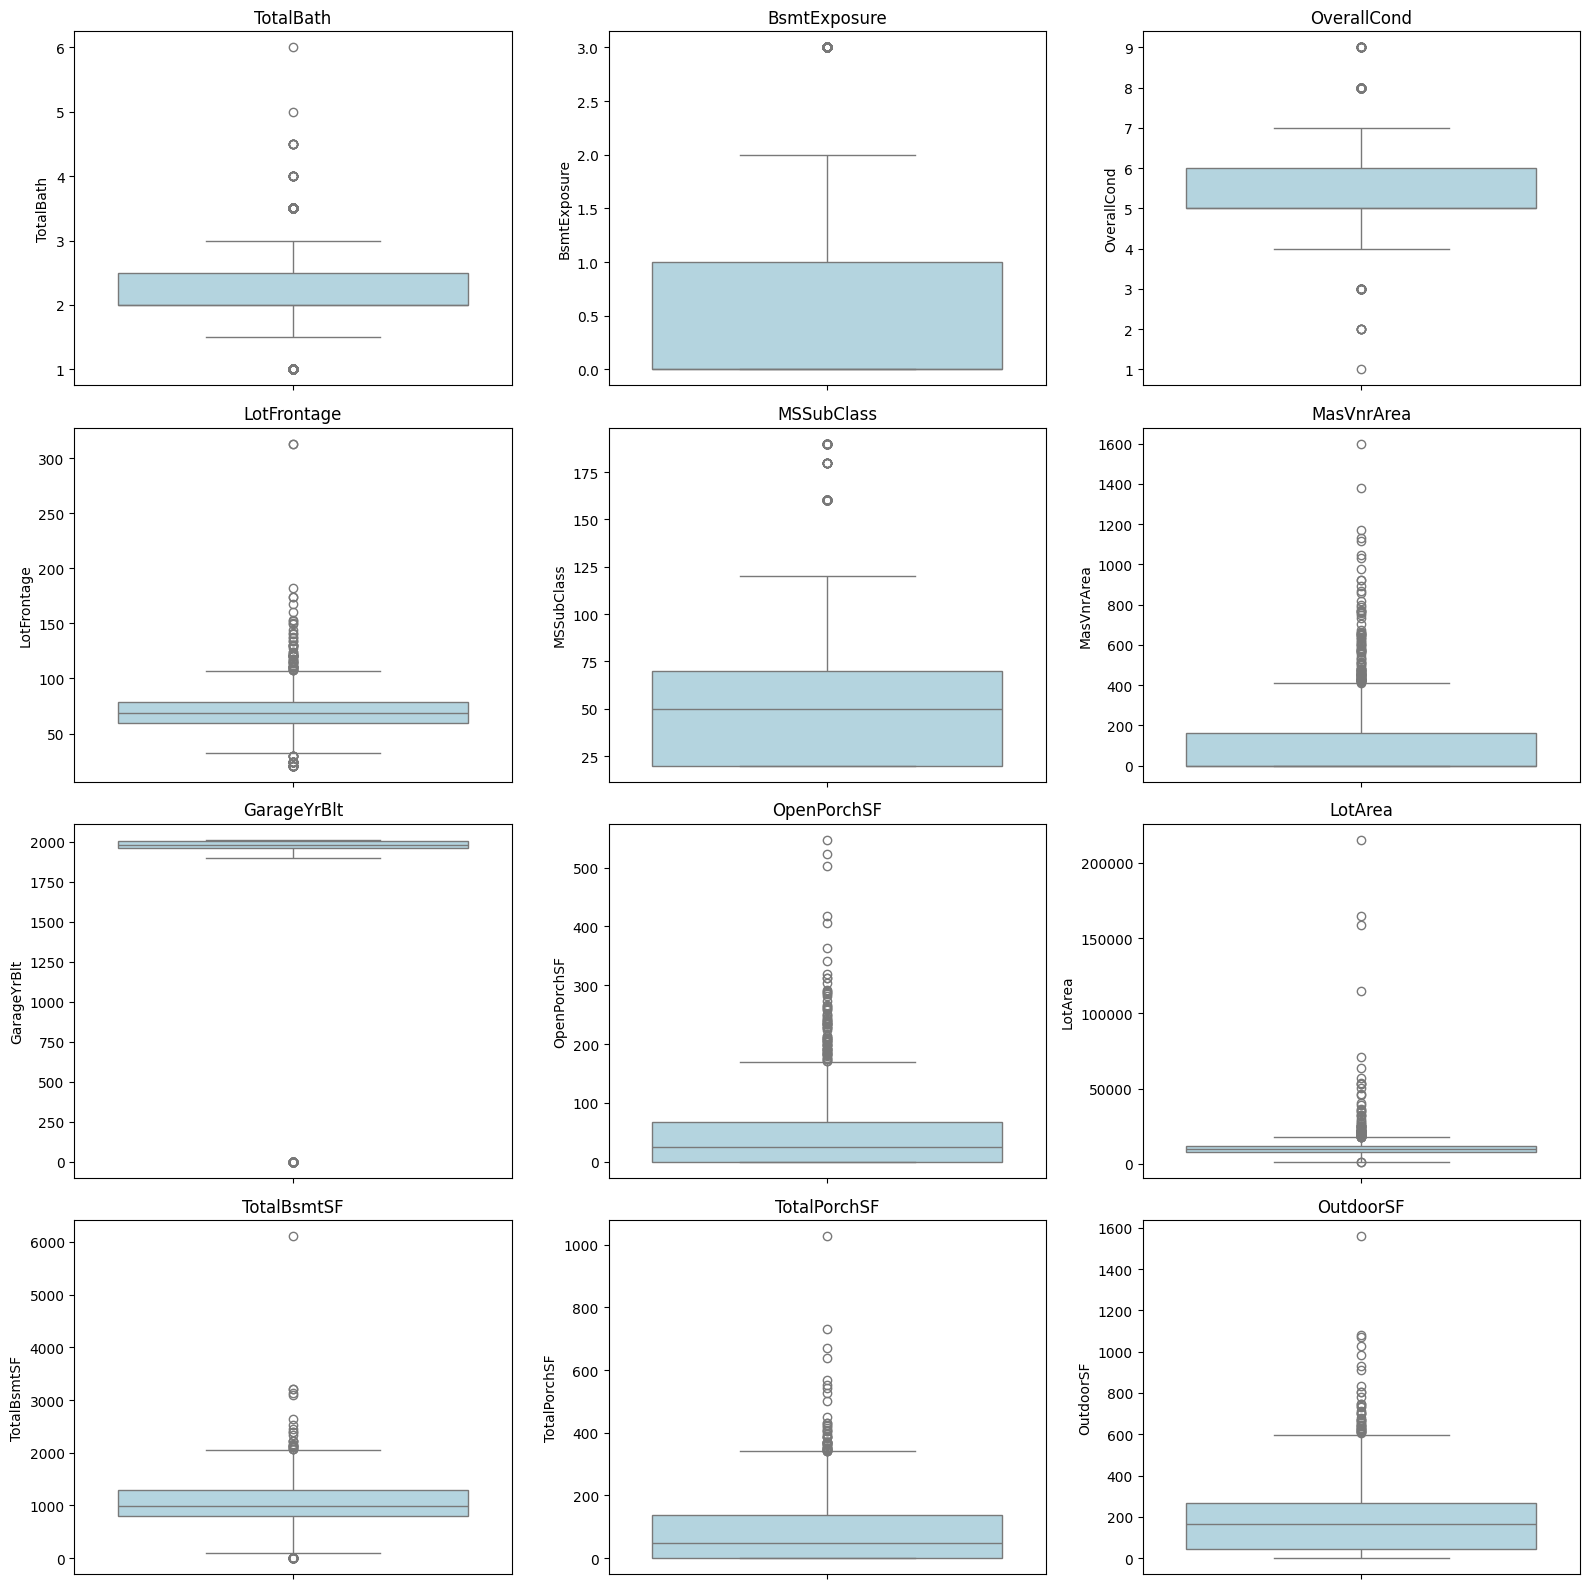

Columns selected for outlier-based row dropping (<10.0% outliers): 30
Rows dropped: 669
Shape before: (1460, 232) | Shape after: (791, 232)


In [36]:
# Boxplot visualization for top outlier columns
top_n = 12
top_outlier_features = outlier_summary['feature'].head(top_n).tolist()

if not top_outlier_features:
    print('No outlier columns detected by IQR rule.')
else:
    ncols = 3
    nrows = int(np.ceil(len(top_outlier_features) / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(top_outlier_features):
        sns.boxplot(y=encoded_train_df[col], ax=axes[i], color='lightblue')
        axes[i].set_title(col)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Drop rows containing outliers only for columns with outlier ratio < 10%
drop_threshold_pct = 10.0
drop_candidate_cols = outlier_summary[outlier_summary['outlier_pct'] < drop_threshold_pct]['feature'].tolist()

rows_to_drop_mask = pd.Series(False, index=encoded_train_df.index)
for col in drop_candidate_cols:
    q1 = encoded_train_df[col].quantile(0.25)
    q3 = encoded_train_df[col].quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    rows_to_drop_mask |= (encoded_train_df[col] < lower) | (encoded_train_df[col] > upper)

rows_to_drop_count = int(rows_to_drop_mask.sum())
encoded_train_df_outliers_dropped = encoded_train_df.loc[~rows_to_drop_mask].copy()

print(f'Columns selected for outlier-based row dropping (<{drop_threshold_pct}% outliers): {len(drop_candidate_cols)}')
print(f'Rows dropped: {rows_to_drop_count}')
print(f'Shape before: {encoded_train_df.shape} | Shape after: {encoded_train_df_outliers_dropped.shape}')


Investigating: TotalBath


count    1460.000000
mean        2.210616
std         0.785399
min         1.000000
25%         2.000000
50%         2.000000
75%         2.500000
max         6.000000
Name: TotalBath, dtype: float64

TotalBathrooms outlier rows by IQR: 394 (26.99%)


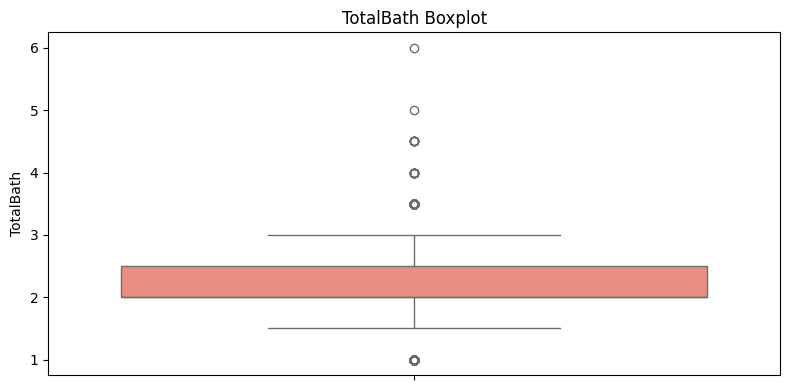

Sample high-end values:


,TotalBath,SalePrice
0,3.5,208500
2,3.5,223500
4,3.5,250000
7,3.5,200000
11,4.0,345000
15,1.0,132000
19,1.0,139000
20,3.5,325300
21,1.0,139400
29,1.0,68500


In [35]:
# Simple investigation for TotalBathrooms
bath_col_candidates = ['TotalBathrooms', 'TotalBath', 'TotalBaths']
bath_col = next((c for c in bath_col_candidates if c in encoded_train_df.columns), None)

if bath_col is None:
    print('No TotalBathrooms-like column found in encoded_train_df.')
else:
    print(f'Investigating: {bath_col}')
    display(encoded_train_df[bath_col].describe())

    q1 = encoded_train_df[bath_col].quantile(0.25)
    q3 = encoded_train_df[bath_col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    bath_outlier_mask = (encoded_train_df[bath_col] < lower) | (encoded_train_df[bath_col] > upper)

    print(f'TotalBathrooms outlier rows by IQR: {int(bath_outlier_mask.sum())} ({100 * bath_outlier_mask.mean():.2f}%)')

    plt.figure(figsize=(8, 4))
    sns.boxplot(y=encoded_train_df[bath_col], color='salmon')
    plt.title(f'{bath_col} Boxplot')
    plt.tight_layout()
    plt.show()

    print('Sample high-end values:')
    display(encoded_train_df.loc[bath_outlier_mask, [bath_col, 'SalePrice']].head(10))
